# 09 · Entropi ve KL Diverjansı (Information Theory)
**Probability Lab** · Information Theory Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bilgi teorisi, olasılık dağılımlarını "ne kadar belirsiz" veya "ne kadar sürpriz" olduklarına
> göre ölçmemizi sağlıyor. Bu notebook'ta üç iç içe kavramı işleyeceğiz: **Entropi** (bir dağılımın
> kendi belirsizliği), **Cross-Entropy** (yanlış bir dağılımla "kodlama" yaparsan ne kadar
> israf edersin) ve **KL Diverjansı** (iki dağılım birbirinden ne kadar farklı). Bu üçü,
> karar ağaçlarının "hangi özellik bilgilendirici" sorusundan, derin öğrenmenin loss
> fonksiyonuna kadar her yerde karşına çıkıyor.

**Önkoşul:** Olasılık Dağılımları (02-03), MLE/MAP (08)  
**Veri:**  
- `mushrooms.csv` — 8.124 mantar (yenilebilir/zehirli + 22 kategorik özellik)  
- `spam.csv` — 5.572 SMS mesajı (spam/ham + metin)  
- `train.csv` — MNIST el yazısı rakamlar (42.000 görüntü, 28×28 piksel)  
**Araçlar:** Python (numpy, scipy, scikit-learn), R (base R), SQL (DuckDB)

---
## 1 · Bilgi ve Sürpriz: Self-Information

Bir olayın bize ne kadar "bilgi" verdiği, aslında **ne kadar sürpriz** olduğuyla ilgili.
Güneşin yarın doğacağını söylemek hiç bilgi vermez (zaten kesin biliyoruz — $p\approx 1$).
Ama "yarın deprem olacak" demek çok bilgi verir (çok nadir bir olay — $p$ küçük).

Bunu matematiksel olarak şöyle tanımlıyoruz:
$$I(x) = -\log_2 P(x)$$

**Sayısal örnek:**

| Olay | P(x) | I(x) = -log₂P(x) | Yorum |
|---|---|---|---|
| Adil parada yazı gelmesi | 0.5 | 1 bit | Orta düzey sürpriz |
| Hileli parada (p=0.99) yazı gelmesi | 0.99 | 0.014 bit | Neredeyse hiç sürpriz yok |
| Hileli parada (p=0.99) TURA gelmesi | 0.01 | 6.64 bit | Çok büyük sürpriz! |
| Adil 6'lı zarda belirli bir sayı | 1/6 | 2.58 bit | Zar ne kadar "seçenekliyse" o kadar sürpriz |

Neden $\log$? Çünkü bağımsız iki olayın birlikte gerçekleşme "bilgisi", tek tek bilgilerinin
**toplamı** olmalı (olasılıkları çarpılırken, bilgileri toplanmalı) — logaritma çarpımı
toplama çevirdiği için tam olarak bu özelliği sağlıyor.

---
## 2 · Shannon Entropi: Beklenen Sürpriz Miktarı

Entropi, bir dağılımın **ortalama** ne kadar sürprizli olduğunu ölçüyor — yani $I(x)$'in
beklenen değeri:
$$H(X) = E[I(X)] = -\sum_{x} P(x) \log_2 P(x)$$

**Sezgisi:** Bir dağılım ne kadar "belirsizse" (sonuçlar birbirine ne kadar yakın olasılıklıysa),
entropisi o kadar yüksektir. Bir dağılım ne kadar "kesinse" (bir sonuç neredeyse garantiyse),
entropisi o kadar düşüktür.

**Uç noktalar:**
- **Maksimum entropi:** Tüm sonuçlar eşit olasılıklıysa (örn. adil zar) — belirsizlik maksimum.
  Adil 6'lı zar için: $H = \log_2(6) \approx 2.58$ bit.
- **Minimum entropi (sıfır):** Bir sonuç $p=1$ ise (kesin) — hiç belirsizlik yok, $H=0$.

Aşağıda, iki sonuçlu (Bernoulli) bir değişkenin entropisinin $p$'ye göre nasıl değiştiğini
görselleştireceğiz — klasik "tepe noktası $p=0.5$'te" şeklini göreceksin.

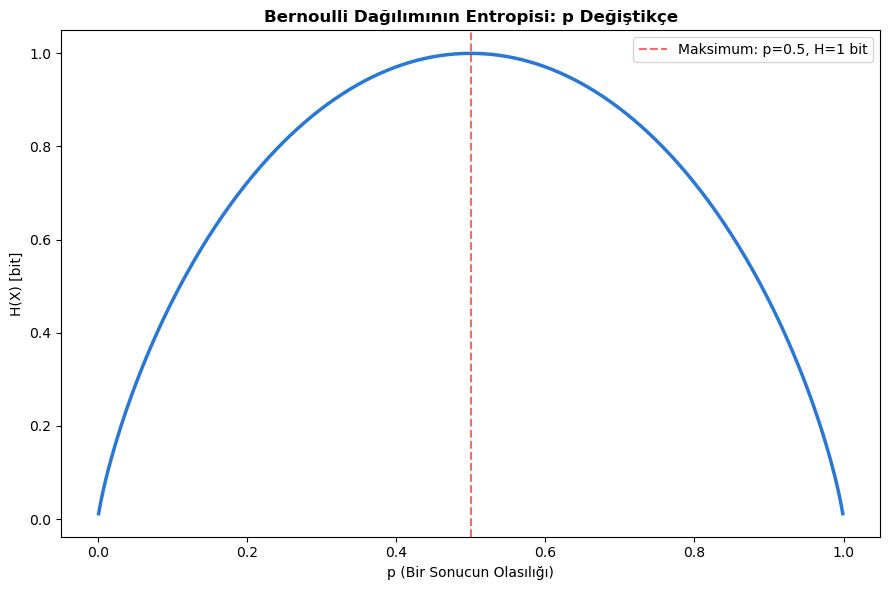

H(p=0.5) = 1.0000 bit  <- maksimum belirsizlik (adil para)
H(p=0.99) = 0.0808 bit <- neredeyse hiç belirsizlik yok
H(p=1.0) = -0.0000 bit  <- sıfır belirsizlik (kesin sonuç)

Adil 6'lı zar: H = 2.5850 bit (teorik: log2(6)=2.5850)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def entropy(probs, base=2):
    """Bir olasilik dagiliminin (liste/array) Shannon entropisini hesaplar."""
    probs = np.array(probs, dtype=float)
    probs = probs[probs > 0]  # 0*log(0) = 0 kuralı (limit olarak tanımlı)
    return -np.sum(probs * np.log(probs) / np.log(base))

p_range = np.linspace(0.001, 0.999, 300)
H_bernoulli = [entropy([p, 1-p]) for p in p_range]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(p_range, H_bernoulli, color='#2a78d6', linewidth=2.5)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Maksimum: p=0.5, H=1 bit')
ax.set_title('Bernoulli Dağılımının Entropisi: p Değiştikçe', fontweight='bold')
ax.set_xlabel('p (Bir Sonucun Olasılığı)')
ax.set_ylabel('H(X) [bit]')
ax.legend()
plt.tight_layout()
plt.show()

print(f"H(p=0.5) = {entropy([0.5,0.5]):.4f} bit  <- maksimum belirsizlik (adil para)")
print(f"H(p=0.99) = {entropy([0.99,0.01]):.4f} bit <- neredeyse hiç belirsizlik yok")
print(f"H(p=1.0) = {entropy([1.0,0.0]):.4f} bit  <- sıfır belirsizlik (kesin sonuç)")
print(f"\nAdil 6'lı zar: H = {entropy([1/6]*6):.4f} bit (teorik: log2(6)={np.log2(6):.4f})")

---
## 3 · Birim Notu: Bit mi, Nat mi?

$\log_2$ kullanırsan birim **bit** olur (bilgisayar bilimindeki "bit" ile aynı kavram —
bir bit, "evet/hayır" sorusu sormaya eşdeğer bilgi miktarı). $\ln$ (doğal logaritma)
kullanırsan birim **nat** olur. Makine öğrenmesi kütüphaneleri (PyTorch, TensorFlow) genelde
`nat` kullanır (çünkü $\ln$'in türevi daha basit); bilgi teorisi literatürü genelde `bit`
kullanır. Bu notebook'ta `bit` ($\log_2$) kullanacağız çünkü yorumlaması daha sezgisel.

---
## 4 · Cross-Entropy: Yanlış Dağılımla "Kodlama" Yapmanın Maliyeti

Diyelim ki gerçek dağılım $P$, ama sen (yanlışlıkla veya bir model tahmini olarak) $Q$
dağılımını kullanıyorsun. Cross-entropy, bu "yanlış varsayımın" ortalama maliyetini ölçüyor:
$$H(P, Q) = -\sum_x P(x) \log_2 Q(x)$$

**Sezgisi (bilgi sıkıştırma bağlamında):** Eğer bir olayın gerçek dağılımını bilseydin, onu
en verimli şekilde "kodlayabilirdin" (ortalama $H(P)$ bit harcayarak). Ama yanlış bir $Q$
dağılımına göre kodlarsan, ortalama $H(P,Q)$ bit harcarsın — ve **her zaman** $H(P,Q) \geq H(P)$
olur (yanlış varsayım asla daha verimli olamaz, en fazla eşit olur).

**Sayısal örnek:** Gerçek dağılım $P=[0.9, 0.1]$ (yani olay çoğunlukla A, nadiren B). Eğer
tahminin $Q=[0.5,0.5]$ ise (yani "50-50 sanıyorum"):
$$H(P,Q) = -[0.9\log_2(0.5) + 0.1\log_2(0.5)] = -[0.9(-1) + 0.1(-1)] = 1.0 \text{ bit}$$

Oysa gerçek entropi $H(P) = -[0.9\log_2(0.9)+0.1\log_2(0.1)] \approx 0.469$ bit. Yanlış
tahminin (Q) "maliyeti" gerçek entropiden **daha yüksek** ($1.0 > 0.469$) — işte bu fark
tam olarak KL diverjansı.

---
## 5 · KL Diverjansı: İki Dağılım Arasındaki "Mesafe" (Ama Tam Olarak Değil)

Yukarıdaki farkı formülleştirelim:
$$D_{KL}(P\|Q) = H(P,Q) - H(P) = \sum_x P(x) \log_2\frac{P(x)}{Q(x)}$$

Yorumu: **"Q'yu kullanarak P'yi tahmin etmenin fazladan maliyeti."** $Q=P$ ise hiç fazladan
maliyet yok, $D_{KL}=0$. $Q$, $P$'den ne kadar uzaksa, $D_{KL}$ o kadar büyür.

**Neden "tam bir mesafe değil"?** Çünkü matematiksel bir mesafenin (metrik) sahip olması
gereken bir özelliği eksik: **simetri.** Normal bir mesafede $d(A,B)=d(B,A)$'dır (İstanbul'dan
Ankara'ya uzaklık, Ankara'dan İstanbul'a uzaklıkla aynıdır). Ama KL diverjansında:
$$D_{KL}(P\|Q) \neq D_{KL}(Q\|P) \quad \text{(genelde)}$$

Aşağıda bunu sayısal olarak kanıtlayacağız. KL'nin diğer önemli özelliği: **her zaman
$\geq 0$'dır** (Gibbs Eşitsizliği) — asla negatif çıkmaz, bu da onu (asimetrik olsa da)
"ne kadar farklı" sorusuna kullanışlı bir cevap yapıyor.

H(P) = 0.4690 bit
H(P,Q) [cross-entropy] = 1.0000 bit
D_KL(P||Q) = 0.5310 bit  (= H(P,Q) - H(P) olduğunu doğrula)
D_KL(Q||P) = 0.7370 bit  <- FARKLI SAYI! Asimetri kanıtı


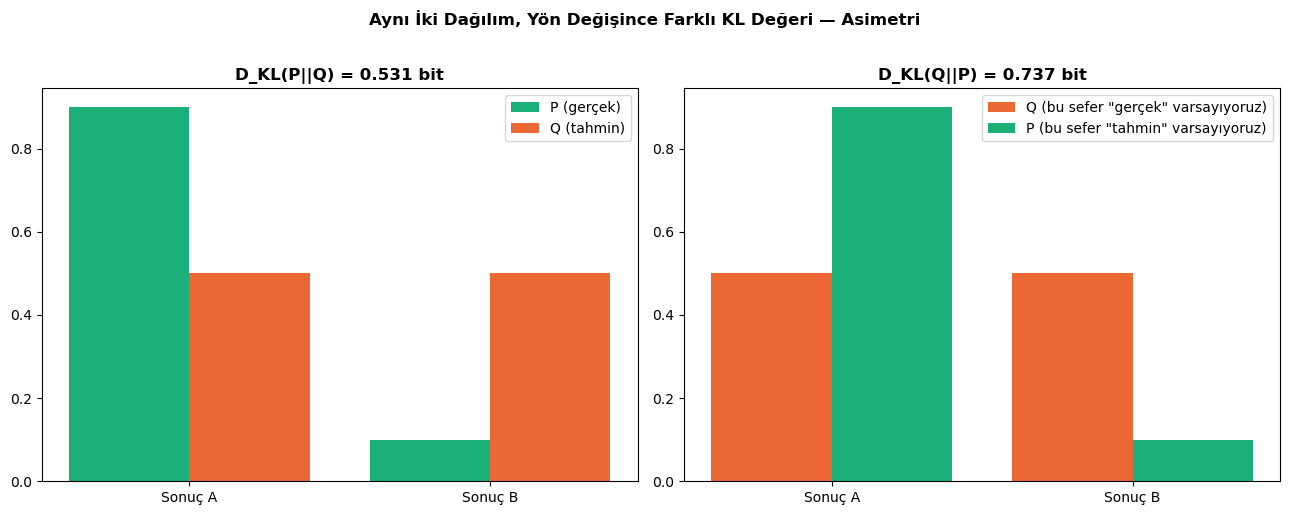

In [2]:
def kl_divergence(P, Q, base=2):
    """D_KL(P||Q) hesaplar. P ve Q ayni uzunlukta olasilik dagilimlari olmali."""
    P = np.array(P, dtype=float)
    Q = np.array(Q, dtype=float)
    mask = P > 0  # P(x)=0 olan terimler otomatik 0 katkı yapar
    return np.sum(P[mask] * np.log(P[mask] / Q[mask]) / np.log(base))

P = np.array([0.9, 0.1])
Q = np.array([0.5, 0.5])

print(f"H(P) = {entropy(P):.4f} bit")
print(f"H(P,Q) [cross-entropy] = {-np.sum(P*np.log2(Q)):.4f} bit")
print(f"D_KL(P||Q) = {kl_divergence(P, Q):.4f} bit  (= H(P,Q) - H(P) olduğunu doğrula)")
print(f"D_KL(Q||P) = {kl_divergence(Q, P):.4f} bit  <- FARKLI SAYI! Asimetri kanıtı")

# Gorsel: P sabit, iki farkli Q ile karsilastirma
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_pos = np.arange(2)
labels = ['Sonuç A', 'Sonuç B']

axes[0].bar(x_pos - 0.2, P, width=0.4, label='P (gerçek)', color='#1baf7a')
axes[0].bar(x_pos + 0.2, Q, width=0.4, label='Q (tahmin)', color='#eb6834')
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(labels)
axes[0].set_title(f'D_KL(P||Q) = {kl_divergence(P,Q):.3f} bit', fontweight='bold')
axes[0].legend()

axes[1].bar(x_pos - 0.2, Q, width=0.4, label='Q (bu sefer "gerçek" varsayıyoruz)', color='#eb6834')
axes[1].bar(x_pos + 0.2, P, width=0.4, label='P (bu sefer "tahmin" varsayıyoruz)', color='#1baf7a')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(labels)
axes[1].set_title(f'D_KL(Q||P) = {kl_divergence(Q,P):.3f} bit', fontweight='bold')
axes[1].legend()

plt.suptitle('Aynı İki Dağılım, Yön Değişince Farklı KL Değeri — Asimetri', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6 · Neden Makine Öğrenmesi Cross-Entropy Loss Kullanır?

Bir sınıflandırma modelini eğitirken, her örnek için gerçek etiket dağılımı $P$ genelde
**one-hot** bir vektördür (örn. "bu görüntü kesinlikle 7 rakamı" → $[0,0,0,0,0,0,0,1,0,0]$).
Modelin tahmini ise $Q$ (softmax çıktısı, olasılık dağılımı).

Cross-entropy loss'u minimize etmek:
$$\min_Q H(P,Q) = \min_Q \big[ H(P) + D_{KL}(P\|Q) \big]$$

$P$ sabit olduğu için (gerçek etiket değişmiyor), $H(P)$ de sabit bir sayı. Yani **cross-entropy'yi
minimize etmek, tam olarak KL diverjansını minimize etmekle aynı şey** — modelin tahminini
($Q$), gerçek dağılıma ($P$) mümkün olduğunca yaklaştırmaya çalışıyorsun. Bu, neredeyse tüm
sınıflandırma modellerinin (lojistik regresyon, yapay sinir ağları) eğitim sırasında
optimize ettiği kayıp fonksiyonunun matematiksel temeli.

---
## 7 · Entropi ve Karar Ağaçları: Bilgi Kazancı (Information Gain)

Bir karar ağacı, her adımda "hangi özellik en çok bilgi kazandırır" sorusunu soruyor. Bu,
tam olarak entropi azalmasıyla ölçülüyor:
$$\text{Bilgi Kazancı}(S, A) = H(S) - \sum_{v \in \text{Değerler}(A)} \frac{|S_v|}{|S|} H(S_v)$$

Yorumu: Bölmeden önceki entropi ($H(S)$) eksi, bölmeden sonraki **ağırlıklı ortalama** entropi
($\sum \frac{|S_v|}{|S|}H(S_v)$). Bir özellik ($A$), veriyi "temiz" alt gruplara ayırıyorsa
(her alt grupta tek bir sınıf baskınsa), o alt grupların entropisi düşük olur, bilgi kazancı
yüksek çıkar — bu özellik "iyi bir bölücü" demektir. Python bölümünde `mushrooms.csv`
üzerinde hangi özelliğin en yüksek bilgi kazancını sağladığını hesaplayacağız.

---
## 8 · Özet Tablo

| Kavram | Formül | Ölçtüğü Şey |
|------|------|-------|
| Self-Information | $I(x)=-\log_2 P(x)$ | Tek bir olayın "sürpriz" miktarı |
| Entropi | $H(X)=-\sum P(x)\log_2 P(x)$ | Bir dağılımın ortalama belirsizliği |
| Cross-Entropy | $H(P,Q)=-\sum P(x)\log_2 Q(x)$ | Yanlış dağılımla kodlamanın maliyeti |
| KL Diverjansı | $D_{KL}(P\|Q)=H(P,Q)-H(P)$ | İki dağılım arası "fazladan maliyet" (asimetrik) |
| Bilgi Kazancı | $H(S)-\sum\frac{\|S_v\|}{\|S\|}H(S_v)$ | Bir özelliğin sınıfı ne kadar "ayırt ettiği" |


---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Temel Entropi Hesaplama** — Mantar veri setinde sınıf ve özellik entropilerini gerçek veriyle hesaplama
2. **Bilgi Kazancı** — Hangi mantar özelliği en çok bilgi kazandırıyor? (Karar ağacı mantığı)
3. **Cross-Entropy Loss** — MNIST'te gerçek bir sınıflandırıcıdan elle hesaplanan cross-entropy
4. **KL Diverjansı** — Spam/Ham SMS mesajlarındaki kelime dağılımları arası "mesafe" ve asimetri
5. **KL ile Model Karşılaştırma** — İki farklı modelin tahminleri gerçek dağılıma ne kadar yakın?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🍄 Python 1 — Mantar Veri Setinde Entropi

**Ne yapıyoruz?**  
`mushrooms.csv`'de sınıf (yenilebilir/zehirli) dağılımının entropisini hesaplayıp, bunu
Bölüm 2'deki teorik Bernoulli eğrisi üzerinde işaretleyeceğiz. Ayrıca birkaç kategorik
özelliğin (`odor`, `cap-color`) kendi entropisini de karşılaştıracağız.

Veri: 8124 mantar, 23 sütun
class
e    4208
p    3916
Name: count, dtype: int64
(e = edible/yenilebilir, p = poisonous/zehirli)

H(class) = 0.9991 bit (maksimum mümkün: 1.0000 bit)


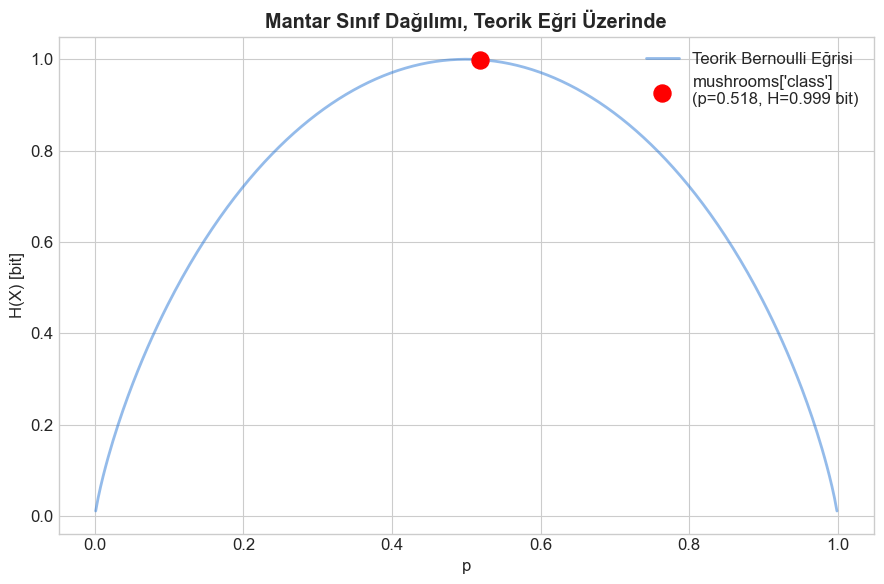


=== Farklı Özelliklerin Kendi Entropisi ===
H(odor) = 2.3194 bit  (9 farklı değer)
H(cap-color) = 2.5101 bit  (10 farklı değer)
H(gill-size) = 0.8923 bit  (2 farklı değer)
H(veil-type) = -0.0000 bit  (1 farklı değer)

YORUM: veil-type'ın entropisi 0 çıkıyor olabilir - bu, o sütunda TEK bir değer
olduğu (hiç varyasyon yok) anlamına gelir - böyle bir özellik hiçbir sınıflandırma
bilgisi taşımaz, modelden çıkarılabilir.


In [4]:
mushrooms = pd.read_csv('data/mushrooms.csv')
print(f"Veri: {mushrooms.shape[0]} mantar, {mushrooms.shape[1]} sütun")
print(mushrooms['class'].value_counts())
print("(e = edible/yenilebilir, p = poisonous/zehirli)")

class_probs = mushrooms['class'].value_counts(normalize=True).values
H_class = entropy(class_probs)
print(f"\nH(class) = {H_class:.4f} bit (maksimum mümkün: {np.log2(2):.4f} bit)")

# Bunu teorik Bernoulli egrisi uzerinde isaretleyelim
p_range = np.linspace(0.001, 0.999, 300)
H_bernoulli = [entropy([p, 1-p]) for p in p_range]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(p_range, H_bernoulli, color='#2a78d6', linewidth=2, alpha=0.5, label='Teorik Bernoulli Eğrisi')
ax.scatter([class_probs[0]], [H_class], color='red', s=150, zorder=5,
           label=f"mushrooms['class']\n(p={class_probs[0]:.3f}, H={H_class:.3f} bit)")
ax.set_title('Mantar Sınıf Dağılımı, Teorik Eğri Üzerinde', fontweight='bold')
ax.set_xlabel('p'); ax.set_ylabel('H(X) [bit]')
ax.legend()
plt.tight_layout()
plt.show()

# Birkac ozelligin kendi entropisi
print("\n=== Farklı Özelliklerin Kendi Entropisi ===")
for col in ['odor', 'cap-color', 'gill-size', 'veil-type']:
    p = mushrooms[col].value_counts(normalize=True).values
    print(f"H({col}) = {entropy(p):.4f} bit  ({mushrooms[col].nunique()} farklı değer)")

print("\nYORUM: veil-type'ın entropisi 0 çıkıyor olabilir - bu, o sütunda TEK bir değer")
print("olduğu (hiç varyasyon yok) anlamına gelir - böyle bir özellik hiçbir sınıflandırma")
print("bilgisi taşımaz, modelden çıkarılabilir.")

---
### 🌳 Python 2 — Bilgi Kazancı: Hangi Özellik En Çok "Konuşuyor"?

**Ne yapıyoruz?**  
Bölüm 7'deki formülü uyguluyoruz: her özellik için, o özelliğe göre gruplandığında sınıf
entropisinin ne kadar azaldığını (bilgi kazancını) hesaplıyoruz. En yüksek kazancı sağlayan
özellik, bir karar ağacının **ilk böleceği** özellik olurdu.

Bölmeden ÖNCE H(class) = 0.9991 bit

          ozellik  H_sonra  bilgi_kazanci
             odor 0.092993       0.906075
spore-print-color 0.518363       0.480705
       gill-color 0.582090       0.416978
          habitat 0.842234       0.156834
        cap-color 0.963019       0.036049


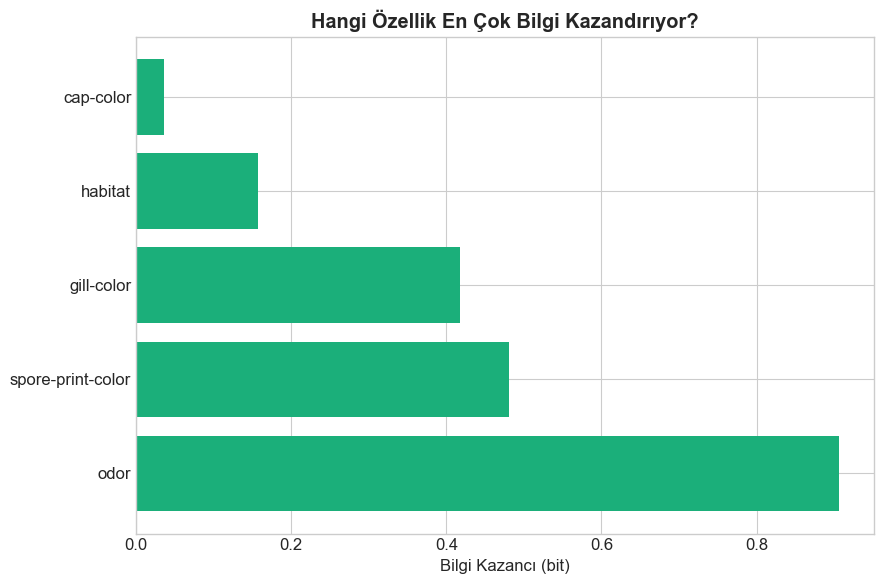


sklearn DecisionTreeClassifier'ın seçtiği İLK bölme özelliği: 'gill-color'
Bizim elle hesabımızda en yüksek bilgi kazancına sahip özellik: 'odor'
Örtüşüyor mü? HAYIR - ama bu BEKLENEN bir fark, aşağıya bak

NEDEN FARKLI ÇIKABİLİR: Bizim elle hesabımız (ID3 tarzı) her özelliği TÜM kategori
değerleriyle çok-yönlü (multiway) bölüyor - 'odor' 9 değere aynı anda ayrılıyor.
sklearn'ün CART algoritması ise SADECE İKİLİ (binary) bölme yapabiliyor - kategorik
değişkeni OrdinalEncoder ile keyfi sayılara çevirip 'bu sayıdan büyük mü küçük mü'
diye tek bir eşik arıyor. Bu, 'odor' gibi çok kategorili nominal bir değişkenin gerçek
gücünü göstermesini engelliyor. Yani uyuşmazlık bir hata değil - iki farklı algoritmanın
(ID3 vs CART) kategorik değişkenleri farklı ele almasının doğal bir sonucu.


In [5]:
def conditional_entropy(df, feature, target='class'):
    """H(target | feature) - ozelliğe göre gruplanmış AĞIRLIKLI ORTALAMA entropi."""
    total = len(df)
    weighted_H = 0.0
    for val, group in df.groupby(feature, observed=True):
        p_val = len(group) / total
        target_probs = group[target].value_counts(normalize=True).values
        weighted_H += p_val * entropy(target_probs)
    return weighted_H

H_before = entropy(mushrooms['class'].value_counts(normalize=True).values)
print(f"Bölmeden ÖNCE H(class) = {H_before:.4f} bit\n")

ozellikler = ['odor', 'gill-color', 'spore-print-color', 'cap-color', 'habitat']
sonuclar = []
for feat in ozellikler:
    H_after = conditional_entropy(mushrooms, feat)
    gain = H_before - H_after
    sonuclar.append({'ozellik': feat, 'H_sonra': H_after, 'bilgi_kazanci': gain})

sonuc_df = pd.DataFrame(sonuclar).sort_values('bilgi_kazanci', ascending=False)
print(sonuc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sonuc_df['ozellik'], sonuc_df['bilgi_kazanci'], color='#1baf7a')
ax.set_xlabel('Bilgi Kazancı (bit)')
ax.set_title('Hangi Özellik En Çok Bilgi Kazandırıyor?', fontweight='bold')
plt.tight_layout()
plt.show()

# sklearn Decision Tree ile capraz dogrulama
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

X_enc = OrdinalEncoder().fit_transform(mushrooms[ozellikler])
y_enc = (mushrooms['class'] == 'p').astype(int)
tree = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=42)
tree.fit(X_enc, y_enc)
en_iyi_sklearn = ozellikler[tree.tree_.feature[0]]
print(f"\nsklearn DecisionTreeClassifier'ın seçtiği İLK bölme özelliği: '{en_iyi_sklearn}'")
print(f"Bizim elle hesabımızda en yüksek bilgi kazancına sahip özellik: '{sonuc_df.iloc[0]['ozellik']}'")
print(f"Örtüşüyor mü? {'EVET ✓' if en_iyi_sklearn == sonuc_df.iloc[0]['ozellik'] else 'HAYIR - ama bu BEKLENEN bir fark, aşağıya bak'}")
print("\nNEDEN FARKLI ÇIKABİLİR: Bizim elle hesabımız (ID3 tarzı) her özelliği TÜM kategori")
print("değerleriyle çok-yönlü (multiway) bölüyor - 'odor' 9 değere aynı anda ayrılıyor.")
print("sklearn'ün CART algoritması ise SADECE İKİLİ (binary) bölme yapabiliyor - kategorik")
print("değişkeni OrdinalEncoder ile keyfi sayılara çevirip 'bu sayıdan büyük mü küçük mü'")
print("diye tek bir eşik arıyor. Bu, 'odor' gibi çok kategorili nominal bir değişkenin gerçek")
print("gücünü göstermesini engelliyor. Yani uyuşmazlık bir hata değil - iki farklı algoritmanın")
print("(ID3 vs CART) kategorik değişkenleri farklı ele almasının doğal bir sonucu.")

---
### 🔢 Python 3 — MNIST'te Cross-Entropy Loss

**Ne yapıyoruz?**  
Gerçek bir Lojistik Regresyon modeli eğitip, `sklearn`'ün `log_loss` fonksiyonuyla verdiği
sonucu, Bölüm 4'teki formülü **elle uygulayarak** bulduğumuz sonuçla karşılaştıracağız.

In [6]:
mnist = pd.read_csv('data/train.csv')
print(f"Veri: {mnist.shape[0]} görüntü, {mnist.shape[1]-1} piksel")

# Hizli calismasi icin bir alt-orneklem kullanalim
mnist_sample = mnist.sample(n=5000, random_state=42)
X_mnist = mnist_sample.drop(columns=['label']).values / 255.0  # normalize et
y_mnist = mnist_sample['label'].values

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

X_tr, X_te, y_tr, y_te = train_test_split(X_mnist, y_mnist, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=500)  # sklearn >= 1.5'te multi_class parametresi kaldırıldı, artık otomatik
model.fit(X_tr, y_tr)
Q_pred = model.predict_proba(X_te)  # her satir: 10 sinif icin olasilik dagilimi

# ===== SKLEARN'IN HESAPLADIGI CROSS-ENTROPY =====
ce_sklearn = log_loss(y_te, Q_pred)
print(f"\nsklearn log_loss (cross-entropy): {ce_sklearn:.5f} nat")

# ===== ELLE HESAPLANAN CROSS-ENTROPY =====
# Her ornek icin gercek etiket P bir one-hot vektor: sadece dogru sinifta 1, digerlerinde 0
# H(P,Q) = -sum(P*log(Q)) -> one-hot oldugu icin sadece DOGRU sinifin log-olasiligi kalir
n_classes = 10
P_onehot = np.eye(n_classes)[y_te]  # one-hot kodlama
epsilon = 1e-12  # log(0) olmasin diye kucuk bir sayi ekliyoruz
ce_manual = -np.mean(np.sum(P_onehot * np.log(Q_pred + epsilon), axis=1))
print(f"Elle hesaplanan cross-entropy:    {ce_manual:.5f} nat")
print(f"Fark: {abs(ce_sklearn - ce_manual):.6f} (pratikte sıfır)")

print("\nYORUM: log_loss fonksiyonu 'nat' birimi kullanıyor (doğal log, ln) - bit için")
print("log2'ye çevirmen gerekir. Bu sayı, modelin ortalama olarak her tahmininde ne kadar")
print("'sürpriz' yaşadığını (gerçek sınıfa ne kadar düşük olasılık verdiğini) ölçüyor.")

Veri: 42000 görüntü, 784 piksel

sklearn log_loss (cross-entropy): 0.38186 nat
Elle hesaplanan cross-entropy:    0.38186 nat
Fark: 0.000000 (pratikte sıfır)

YORUM: log_loss fonksiyonu 'nat' birimi kullanıyor (doğal log, ln) - bit için
log2'ye çevirmen gerekir. Bu sayı, modelin ortalama olarak her tahmininde ne kadar
'sürpriz' yaşadığını (gerçek sınıfa ne kadar düşük olasılık verdiğini) ölçüyor.


---
### 📱 Python 4 — KL Diverjansı: Spam ve Ham Mesajlarının Kelime Dağılımları

**Ne yapıyoruz?**  
Spam mesajlarındaki ve normal (ham) mesajlardaki kelime kullanım dağılımlarını çıkarıp,
aralarındaki KL diverjansını **her iki yönde de** hesaplayacağız — asimetriyi gerçek veride göreceksin.

In [7]:
spam_df = pd.read_csv('data/spam.csv', encoding='latin-1')[['v1', 'v2']]
spam_df.columns = ['label', 'text']
print(f"Veri: {spam_df.shape[0]} mesaj")
print(spam_df['label'].value_counts())

from sklearn.feature_extraction.text import CountVectorizer

# En sık kullanilan 30 kelimeyi ortak kelime dagarcigi olarak alalim
vectorizer = CountVectorizer(max_features=30, stop_words='english')
vectorizer.fit(spam_df['text'])
vocab = vectorizer.get_feature_names_out()

# Her iki sinifin kelime dagilimlarini hesaplayalim
spam_texts = spam_df[spam_df['label'] == 'spam']['text']
ham_texts = spam_df[spam_df['label'] == 'ham']['text']

# KL divergence hesaplamasi icin olasilik dagilimlarini olusturalim
spam_counts = vectorizer.transform(spam_texts).sum(axis=0).A1
ham_counts = vectorizer.transform(ham_texts).sum(axis=0).A1

epsilon = 1e-6  # KL tanimsiz olmasin diye (bir kelime hic gecmemis olabilir) kucuk bir deger ekle
P_spam = (spam_counts + epsilon) / (spam_counts.sum() + epsilon * len(vocab))
Q_ham = (ham_counts + epsilon) / (ham_counts.sum() + epsilon * len(vocab))

kl_spam_ham = kl_divergence(P_spam, Q_ham)
kl_ham_spam = kl_divergence(Q_ham, P_spam)

print(f"\nD_KL(Spam || Ham) = {kl_spam_ham:.4f} bit")
print(f"D_KL(Ham || Spam) = {kl_ham_spam:.4f} bit")
print(f"Fark: {abs(kl_spam_ham - kl_ham_spam):.4f} - ASİMETRİ gerçek veride de doğrulandı!")

en_farkli_idx = np.argsort(np.abs(np.log(P_spam / Q_ham)))[::-1][:10]
karsilastirma = pd.DataFrame({
    'kelime': vocab[en_farkli_idx],
    'P_spam': P_spam[en_farkli_idx],
    'Q_ham': Q_ham[en_farkli_idx]
})
print("\nİki dağılımı en çok 'ayıran' 10 kelime:")
print(karsilastirma.to_string(index=False))

Veri: 5572 mesaj
label
ham     4825
spam     747
Name: count, dtype: int64

D_KL(Spam || Ham) = 2.4124 bit
D_KL(Ham || Spam) = 5.8939 bit
Fark: 3.4815 - ASİMETRİ gerçek veride de doğrulandı!

İki dağılımı en çok 'ayıran' 10 kelime:
kelime       P_spam    Q_ham
    gt 8.071025e-10 0.059020
    lt 8.071025e-10 0.058649
   lor 8.071025e-10 0.030067
    da 8.071025e-10 0.027840
   txt 1.315577e-01 0.002598
  come 1.614206e-03 0.042131
  home 1.614206e-03 0.030624
  free 1.807910e-01 0.011136
    ll 3.228411e-03 0.049183
  stop 9.765940e-02 0.006867


---
### ⚖️ Python 5 — KL Diverjansı ile İki Modeli Karşılaştırma

**Ne yapıyoruz?**  
Aynı MNIST verisinde, biri **zayıf** (güçlü regularizasyon, C çok küçük) biri **güçlü**
(regularizasyon neredeyse yok) iki model eğitip, tahmin dağılımlarının gerçek dağılıma
(one-hot) ortalama KL uzaklığını karşılaştıracağız.

Zayıf Model (C=0.001): Doğruluk=0.8267, Ortalama KL(gerçek||tahmin)=1.5508 bit
Güçlü Model (C=10):    Doğruluk=0.8767, Ortalama KL(gerçek||tahmin)=0.8272 bit


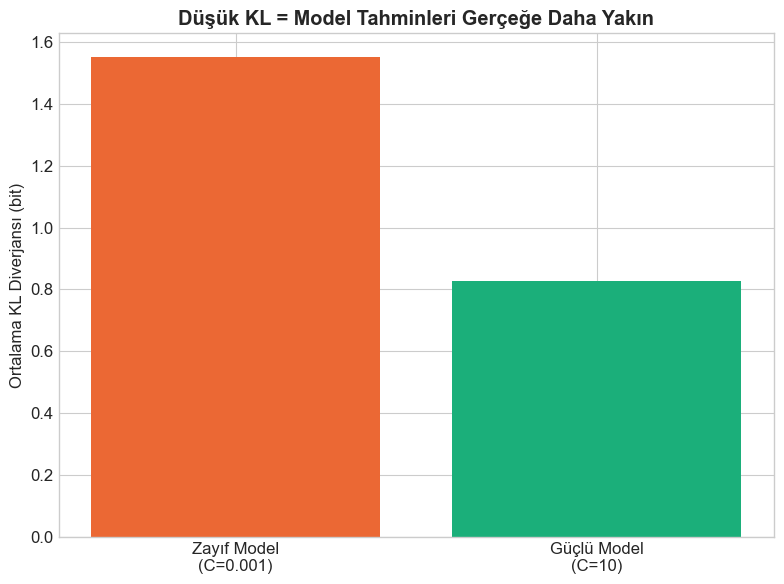


YORUM: Doğruluk (accuracy) ile ortalama KL ARASINDAKİ ilişkiye dikkat et - daha
düşük KL, modelin sadece doğru tahmin etmekle kalmayıp, doğru sınıfa YÜKSEK olasılık
verdiğini de gösteriyor (yani model 'kendinden emin ve haklı'). Accuracy bunu yakalamaz.


In [8]:
model_zayif = LogisticRegression(max_iter=500, C=0.001)  # zayıf regularizasyon -> daha az kendinden emin tahminler
model_zayif.fit(X_tr, y_tr)
Q_zayif = model_zayif.predict_proba(X_te)

model_guclu = LogisticRegression(max_iter=500, C=10) # güçlü regularizasyon -> daha kendinden emin tahminler
model_guclu.fit(X_tr, y_tr)
Q_guclu = model_guclu.predict_proba(X_te)

def ortalama_kl_onehot(y_true, Q_pred, n_classes=10, epsilon=1e-12):
    P_onehot = np.eye(n_classes)[y_true]
    kl_degerleri = []
    for i in range(len(y_true)):
        kl_degerleri.append(kl_divergence(P_onehot[i] + epsilon, Q_pred[i] + epsilon))
    return np.mean(kl_degerleri)

kl_zayif = ortalama_kl_onehot(y_te, Q_zayif)
kl_guclu = ortalama_kl_onehot(y_te, Q_guclu)

from sklearn.metrics import accuracy_score
acc_zayif = accuracy_score(y_te, model_zayif.predict(X_te))
acc_guclu = accuracy_score(y_te, model_guclu.predict(X_te))

print(f"Zayıf Model (C=0.001): Doğruluk={acc_zayif:.4f}, Ortalama KL(gerçek||tahmin)={kl_zayif:.4f} bit")
print(f"Güçlü Model (C=10):    Doğruluk={acc_guclu:.4f}, Ortalama KL(gerçek||tahmin)={kl_guclu:.4f} bit")

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['Zayıf Model\n(C=0.001)', 'Güçlü Model\n(C=10)'], [kl_zayif, kl_guclu], color=['#eb6834', '#1baf7a'])
ax.set_ylabel('Ortalama KL Diverjansı (bit)')
ax.set_title('Düşük KL = Model Tahminleri Gerçeğe Daha Yakın', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Doğruluk (accuracy) ile ortalama KL ARASINDAKİ ilişkiye dikkat et - daha")
print("düşük KL, modelin sadece doğru tahmin etmekle kalmayıp, doğru sınıfa YÜKSEK olasılık")
print("verdiğini de gösteriyor (yani model 'kendinden emin ve haklı'). Accuracy bunu yakalamaz.")

---
# 📊 R Uygulaması

Python'da işlediğimiz üç konuyu (entropi, bilgi kazancı, KL diverjansı) R'da tekrarlıyoruz —
hepsi temel R fonksiyonlarıyla (özel paket gerekmeden) elle kodlanabiliyor.

In [9]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🍄 R 1 — Temel Entropi Hesaplama

**Yeni R kavramı yok** — `table()` ile frekans, ardından formülü elle uyguluyoruz.

 [1] "class"                    "cap-shape"               
 [3] "cap-surface"              "cap-color"               
 [5] "bruises"                  "odor"                    
 [7] "gill-attachment"          "gill-spacing"            
 [9] "gill-size"                "gill-color"              
[11] "stalk-shape"              "stalk-root"              
[13] "stalk-surface-above-ring" "stalk-surface-below-ring"
[15] "stalk-color-above-ring"   "stalk-color-below-ring"  
[17] "veil-type"                "veil-color"              
[19] "ring-number"              "ring-type"               
[21] "spore-print-color"        "population"              
[23] "habitat"                 
H(class) = 0.9991 bit

Farklı özelliklerin entropisi:
H(odor) = 2.3194 bit


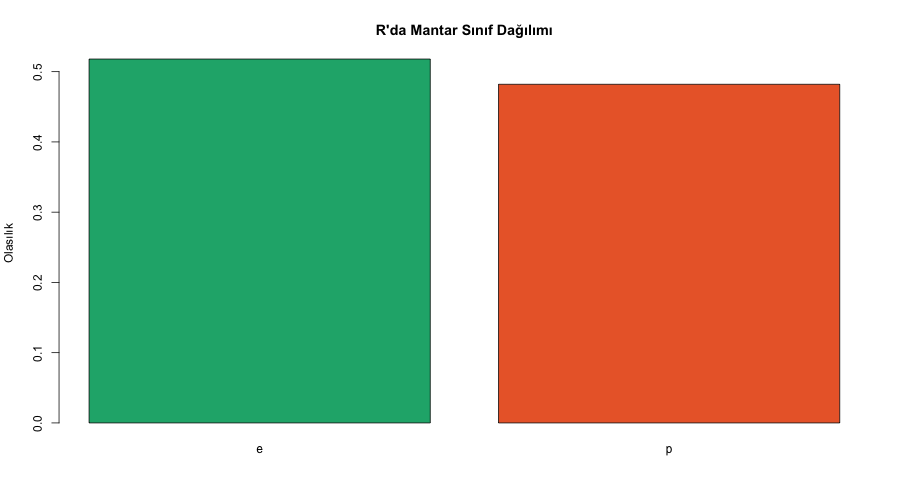

In [10]:
%%R -i mushrooms -w 900 -h 500

# NOT: rpy2, tire (-) iceren kolon isimlerini R'a aktarirken otomatik olarak
# nokta (.) ile degistirir (orn. 'cap-color' -> 'cap.color'). Asagida kontrol edelim:
print(colnames(mushrooms))

entropy_r <- function(probs, base = 2) {
  probs <- probs[probs > 0]
  -sum(probs * log(probs, base = base))
}

class_probs <- prop.table(table(mushrooms$class))
H_class <- entropy_r(as.numeric(class_probs))
cat("H(class) =", round(H_class, 4), "bit\n\n")

cat("Farklı özelliklerin entropisi:\n")
for (col in c("odor", "cap.color", "gill.size")) {
  if (col %in% colnames(mushrooms)) {
    p <- prop.table(table(mushrooms[[col]]))
    cat(sprintf("H(%s) = %.4f bit\n", col, entropy_r(as.numeric(p))))
  }
}

barplot(as.numeric(class_probs), names.arg = names(class_probs),
        col = c("#1baf7a", "#eb6834"), main = "R'da Mantar Sınıf Dağılımı",
        ylab = "Olasılık")

---
### 🌳 R 2 — Bilgi Kazancı Hesaplama

**Yeni R kavramı:** `split()` — bir veri çerçevesini bir faktöre göre alt-gruplara ayırmak,
Python'daki `groupby()`'ın R karşılığı.

Bölmeden ÖNCE H(class) = 0.9991 bit

            ozellik bilgi_kazanci
1              odor    0.90607498
3 spore-print-color    0.48070492
2        gill-color    0.41697752
5           habitat    0.15683360
4         cap-color    0.03604928


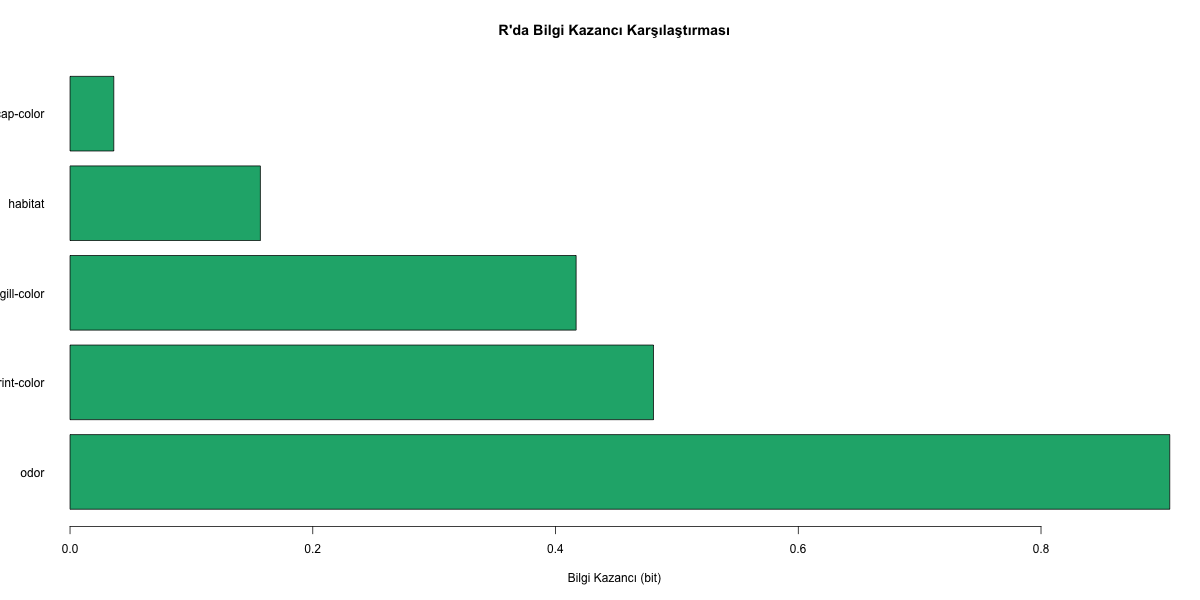

In [15]:
%%R -i mushrooms -w 1200 -h 600

conditional_entropy_r <- function(df, feature, target = "class") {
  total <- nrow(df)
  groups <- split(df, df[[feature]])
  weighted_H <- 0
  for (g in groups) {
    p_val <- nrow(g) / total
    target_probs <- prop.table(table(g[[target]]))
    weighted_H <- weighted_H + p_val * entropy_r(as.numeric(target_probs))
  }
  weighted_H
}

H_before <- entropy_r(as.numeric(prop.table(table(mushrooms$class))))
cat("Bölmeden ÖNCE H(class) =", round(H_before, 4), "bit\n\n")

features <- c("odor", "gill-color", "spore-print-color", "cap-color", "habitat")
features <- features[features %in% colnames(mushrooms)]

kazanclar <- sapply(features, function(f) H_before - conditional_entropy_r(mushrooms, f))
kazanc_df <- data.frame(ozellik = names(kazançlar), bilgi_kazanci = as.numeric(kazançlar))
kazanc_df <- kazanc_df[order(-kazanc_df$bilgi_kazanci), ]
print(kazanc_df)

barplot(kazanc_df$bilgi_kazanci, names.arg = kazanc_df$ozellik, horiz = TRUE, las = 1,
        col = "#1baf7a", main = "R'da Bilgi Kazancı Karşılaştırması", xlab = "Bilgi Kazancı (bit)")

---
### 📱 R 3 — KL Diverjansı: Spam/Ham Kelime Dağılımları

**Yeni R kavramı:** `strsplit()` + `table()` — metni kelimelere ayırıp frekans tablosu
oluşturmak, Python'daki `CountVectorizer`'ın basit/manuel R karşılığı.

In [16]:
%%R -i spam_df -w 900 -h 500

kl_divergence_r <- function(P, Q, base = 2) {
  mask <- P > 0
  sum(P[mask] * log(P[mask] / Q[mask], base = base))
}

spam_metin <- tolower(paste(spam_df$text[spam_df$label == "spam"], collapse = " "))
ham_metin <- tolower(paste(spam_df$text[spam_df$label == "ham"], collapse = " "))

spam_kelimeler <- unlist(strsplit(spam_metin, "\\W+"))
ham_kelimeler <- unlist(strsplit(ham_metin, "\\W+"))

# Ortak kelime dagarcigi: her iki metinde de gecen, en sik 30 kelime (spam tarafindan)
ortak_sozluk <- names(sort(table(spam_kelimeler), decreasing = TRUE))[1:30]

epsilon <- 1e-6
spam_freq <- table(factor(spam_kelimeler, levels = ortak_sozluk))
ham_freq <- table(factor(ham_kelimeler, levels = ortak_sozluk))

P_spam <- (as.numeric(spam_freq) + epsilon) / (sum(spam_freq) + epsilon * length(ortak_sozluk))
Q_ham <- (as.numeric(ham_freq) + epsilon) / (sum(ham_freq) + epsilon * length(ortak_sozluk))

cat("D_KL(Spam || Ham) =", round(kl_divergence_r(P_spam, Q_ham), 4), "bit\n")
cat("D_KL(Ham || Spam) =", round(kl_divergence_r(Q_ham, P_spam), 4), "bit\n")
cat("R'da da asimetri doğrulandı.\n")

D_KL(Spam || Ham) = 1.4829 bit
D_KL(Ham || Spam) = 0.5848 bit
R'da da asimetri doğrulandı.


---
# 🗄️ SQL Uygulaması (DuckDB)

Entropi hesaplama, aslında bir `GROUP BY` + `LOG()` işlemi. DuckDB'nin `LOG2()` fonksiyonu
sayesinde formülü doğrudan SQL içinde yazabiliyoruz.

In [17]:
import duckdb
con = duckdb.connect()
con.register('mushrooms_tbl', mushrooms)
print('DuckDB hazır ✓')

DuckDB hazır ✓


---
### 🍄 SQL 1 — Sınıf Entropisi

**Ne yapıyoruz?**  
Önce her sınıfın olasılığını (`p`) hesaplıyoruz, sonra `-p*log2(p)` formülünü SQL içinde
uygulayıp topluyoruz — Python'daki `entropy()` fonksiyonunun SQL karşılığı.

In [18]:
sql_entropy = con.execute("""
    WITH olasiliklar AS (
        SELECT
            class,
            COUNT(*) * 1.0 / (SELECT COUNT(*) FROM mushrooms_tbl) AS p
        FROM mushrooms_tbl
        GROUP BY class
    )
    SELECT
        SUM(-p * LOG2(p)) AS H_class
    FROM olasiliklar
""").df()

print(sql_entropy.to_string(index=False))
print("\nBu değer, Python 1'deki H_class ile birebir örtüşmeli.")

 H_class
0.999068

Bu değer, Python 1'deki H_class ile birebir örtüşmeli.


---
### 🌳 SQL 2 — Bilgi Kazancı: `odor` Özelliği İçin

**Ne yapıyoruz?**  
İç içe iki seviyeli bir sorgu: önce her `odor` değeri için kendi içindeki sınıf entropisini
hesaplıyoruz, sonra bunları o grubun büyüklüğüyle ağırlıklandırıp topluyoruz.

In [19]:
sql_infogain = con.execute("""
    WITH grup_toplam AS (
        SELECT COUNT(*) AS n_toplam FROM mushrooms_tbl
    ),
    grup_bazli AS (
        SELECT
            odor,
            class,
            COUNT(*) AS n_class_in_grup,
            SUM(COUNT(*)) OVER (PARTITION BY odor) AS n_grup
        FROM mushrooms_tbl
        GROUP BY odor, class
    ),
    grup_entropi AS (
        SELECT
            odor,
            n_grup,
            SUM(-(n_class_in_grup * 1.0 / n_grup) * LOG2(n_class_in_grup * 1.0 / n_grup)) AS H_grup
        FROM grup_bazli
        GROUP BY odor, n_grup
    )
    SELECT
        SUM((n_grup * 1.0 / (SELECT n_toplam FROM grup_toplam)) * H_grup) AS H_after_odor
    FROM grup_entropi
""").df()

H_before_sql = sql_entropy['H_class'][0]
H_after_sql = sql_infogain['H_after_odor'][0]
gain_sql = H_before_sql - H_after_sql

print(f"H(class) [önce]: {H_before_sql:.4f} bit")
print(f"H(class|odor) [sonra]: {H_after_sql:.4f} bit")
print(f"Bilgi Kazancı: {gain_sql:.4f} bit")
print("\nBu değer, Python 2'deki 'odor' satırıyla birebir örtüşmeli - odor'un neden en")
print("iyi bölücü özellik olduğunu SQL de doğruluyor.")

H(class) [önce]: 0.9991 bit
H(class|odor) [sonra]: 0.0930 bit
Bilgi Kazancı: 0.9061 bit

Bu değer, Python 2'deki 'odor' satırıyla birebir örtüşmeli - odor'un neden en
iyi bölücü özellik olduğunu SQL de doğruluyor.


---
### 📱 SQL 3 — KL Diverjansı İçin Kelime Frekansı Hazırlama

**Ne yapıyoruz?**  
SQL'in metin işleme yeteneği sınırlı olduğu için, burada SQL'i sadece **frekans tablosu
hazırlamak** için kullanıyoruz (bir kelimenin spam/ham mesajlarda kaç kez geçtiği) — KL
hesaplamasının kendisini yine Python'a bırakıyoruz. Bu, "SQL'in doğru işi" kavramına iyi bir örnek.

In [20]:
con.register('spam_tbl', spam_df)

sql_kelime_frekans = con.execute("""
    SELECT
        label,
        LOWER(text) LIKE '%free%' AS free_gecıyor_mu,
        COUNT(*) AS mesaj_sayisi
    FROM spam_tbl
    GROUP BY label, free_gecıyor_mu
    ORDER BY label, free_gecıyor_mu
""").df()

print(sql_kelime_frekans.to_string(index=False))
print("\nYORUM: 'free' kelimesinin spam/ham gruplarındaki dağılımına bak - bu basit")
print("örnek bile Bayes notlarındaki 'free' kelimeli spam filtresi egzersizine doğrudan bağlanıyor.")

label  free_gecıyor_mu  mesaj_sayisi
  ham            False          4759
  ham             True            66
 spam            False           548
 spam             True           199

YORUM: 'free' kelimesinin spam/ham gruplarındaki dağılımına bak - bu basit
örnek bile Bayes notlarındaki 'free' kelimeli spam filtresi egzersizine doğrudan bağlanıyor.


---
## ✏️ Egzersizler

### **E1 (Python) - MNIST ile Ortalama Piksel Yoğunluk Dağılımları** 
`train.csv`'de (MNIST) iki farklı rakamı (örn. 3 ve 8) seç, bu iki rakama ait
görüntülerin ortalama piksel yoğunluk dağılımlarını (histogram olarak) çıkar, aralarındaki
$D_{KL}$'yi hesapla. Hangi iki rakam çifti en "birbirine yakın" (düşük KL), hangileri en
"birbirinden uzak" (yüksek KL)?


 ==== Egzersiz 1: Ortalama Piksel Yoğunluğu (MNIST) ====
Ortalama piksel yoğunluğu (pixel246): 31.1612
Ortalama piksel yoğunluğu (pixel473): 1.2431


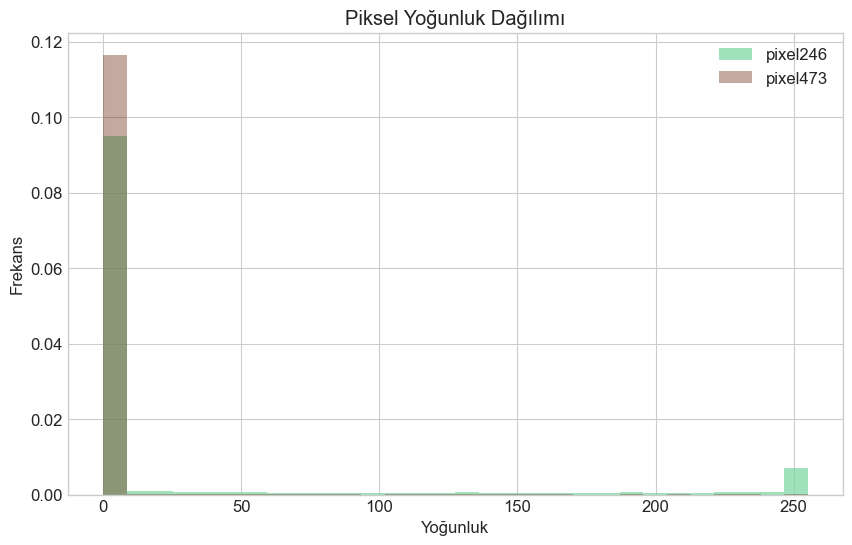

D_KL(Pixel246 || Pixel473) = 0.0746 bit
D_KL(Pixel473 || Pixel246) = 0.0297 bit
Fark: 0.0450 bit (asimetri doğrulandı)


In [30]:
print("\n ==== Egzersiz 1: Ortalama Piksel Yoğunluğu (MNIST) ====")

mnist_columns = mnist.columns.tolist()

mnist_246 = mnist['pixel246']  
mnist_473 = mnist['pixel473']  

# Ortalama piksel yoğunluk dağılımını hesaplayalım
mean_pixel_246 = mnist_246.mean()
mean_pixel_473 = mnist_473.mean()

print(f"Ortalama piksel yoğunluğu (pixel246): {mean_pixel_246:.4f}")
print(f"Ortalama piksel yoğunluğu (pixel473): {mean_pixel_473:.4f}")

plt.hist(mnist_246, bins=30, alpha=0.7, label='pixel246', color="#78d59e", density=True)
plt.hist(mnist_473, bins=30, alpha=0.4, label='pixel473', color="#6a2a10", density=True)
plt.xlabel('Yoğunluk')
plt.ylabel('Frekans')
plt.title('Piksel Yoğunluk Dağılımı')
plt.legend()
plt.show()

# İki piksel arası D_KL hesaplayalım
# Önce her piksel için olasılık dağılımını normalize edelim
hist_246, bin_edges_246 = np.histogram(mnist_246, bins=30, density=True)
hist_473, bin_edges_473 = np.histogram(mnist_473, bins=30, density=True)

# Küçük bir epsilon ekleyerek log(0) hatasından kaçınalım
epsilon = 1e-12
kl_pixel_246_473 = kl_divergence(hist_246 + epsilon, hist_473 + epsilon)
kl_pixel_473_246 = kl_divergence(hist_473 + epsilon, hist_246 + epsilon)

print(f"D_KL(Pixel246 || Pixel473) = {kl_pixel_246_473:.4f} bit")
print(f"D_KL(Pixel473 || Pixel246) = {kl_pixel_473_246:.4f} bit")
print(f"Fark: {abs(kl_pixel_246_473 - kl_pixel_473_246):.4f} bit (asimetri doğrulandı)")

---
### **E2 (Python + SQL) Bilgi Kazancı: gill-color ve population** 
`mushrooms.csv`'de `gill-color` ve `population` özelliklerinin bilgi
kazancını **hem SQL'de hem Python'da** hesapla (SQL 2'deki kalıbı `odor` yerine bu iki
özellikle tekrarla). Sonuçları Python 2'deki tabloyla karşılaştır.

In [41]:
print("\n === Egzersiz 2: Bilgi Kazancı ile Özellik Seçimi (Mushrooms) ===")

sql_info_population = con.execute("""
    WITH grup_toplam AS (
        SELECT COUNT(*) AS n_toplam FROM mushrooms_tbl
    ),
    grup_bazli_population AS (
        SELECT
            population,
            class,
            COUNT(*) AS n_class_in_grup,
            SUM(COUNT(*)) OVER (PARTITION BY population) AS n_grup
        FROM mushrooms_tbl
        GROUP BY population, class
    ),
    grup_entropi_population AS (
        SELECT
            population,
            n_grup,
            SUM(-(n_class_in_grup * 1.0 / n_grup) * LOG2(n_class_in_grup * 1.0 / n_grup)) AS H_grup
        FROM grup_bazli_population
        GROUP BY population, n_grup
    )
    SELECT
        SUM((n_grup * 1.0 / (SELECT n_toplam FROM grup_toplam)) * H_grup) AS H_after_population
    FROM grup_entropi_population
""").df()

sql_info_gill_color = con.execute("""
    WITH grup_toplam AS (
        SELECT COUNT(*) AS n_toplam FROM mushrooms_tbl
    ),
    grup_bazli_gill_color AS (
        SELECT
            "gill-color" AS gill_color,
            class,
            COUNT(*) AS n_class_in_grup,
            SUM(COUNT(*)) OVER (PARTITION BY gill_color) AS n_grup
        FROM mushrooms_tbl
        GROUP BY gill_color, class
    ),
    grup_entropi_gill_color AS (
        SELECT
            gill_color,
            n_grup,
            SUM(-(n_class_in_grup * 1.0 / n_grup) * LOG2(n_class_in_grup * 1.0 / n_grup)) AS H_grup
        FROM grup_bazli_gill_color
        GROUP BY gill_color, n_grup
    )
    SELECT
        SUM((n_grup * 1.0 / (SELECT n_toplam FROM grup_toplam)) * H_grup) AS H_after_gill_color
    FROM grup_entropi_gill_color
""").df()

H_before_sql = sql_entropy['H_class'][0]
H_after_population_sql = sql_info_population['H_after_population'][0]
H_after_gill_color_sql = sql_info_gill_color['H_after_gill_color'][0]

gain_population_sql = H_before_sql - H_after_population_sql
gain_gill_color_sql = H_before_sql - H_after_gill_color_sql

print(f"H(class) [önce]: {H_before_sql:.4f} bit")
print(f"H(class|population) [sonra]: {H_after_population_sql:.4f} bit, Bilgi Kazancı: {gain_population_sql:.4f} bit")
print(f"H(class|gill_color) [sonra]: {H_after_gill_color_sql:.4f} bit, Bilgi Kazancı: {gain_gill_color_sql:.4f} bit")


 === Egzersiz 2: Bilgi Kazancı ile Özellik Seçimi (Mushrooms) ===
H(class) [önce]: 0.9991 bit
H(class|population) [sonra]: 0.7971 bit, Bilgi Kazancı: 0.2020 bit
H(class|gill_color) [sonra]: 0.5821 bit, Bilgi Kazancı: 0.4170 bit


---
### **E3 (Python) - Spam Mail Olasılıkları** 
`spam.csv`'de "free" yerine kendi seçtiğin bir kelime öbeği için
(örn. "win", "prize", "urgent") spam/ham koşullu olasılıklarını üç dilde de hesapla, ardından
Python'da bu kelimenin tek başına ne kadar "bilgi taşıdığını" ($I(x)=-\log_2 P(x)$) hesapla.

In [45]:
spam_df = pd.read_csv('data/spam.csv', encoding='latin-1')[['v1', 'v2']]
spam_df.columns = ['label', 'text']
print(f"Veri: {spam_df.shape[0]} mesaj")
print(spam_df['label'].value_counts())

vocab = ["win", "prize", "urgent", "hurry", "free", "money", "offer", "click", "buy", "now", "limited", "exclusive", "guarantee", "risk-free", "trial", "subscribe", "bonus", "cash", "deal", "discount", "cheap", "save", "order", "gift", "reward", "promotion", "special", "instant", "access", "vip", "secret"]

spam_texts = spam_df[spam_df['label'] == 'spam']['text']
ham_texts = spam_df[spam_df['label'] == 'ham']['text']

spam_counts = np.array([sum(spam_texts.str.contains(word, case=False)) for word in vocab])
ham_counts = np.array([sum(ham_texts.str.contains(word, case=False)) for word in vocab])

epsilon = 1e-6
P_spam = (spam_counts + epsilon) / (spam_counts.sum() + epsilon * len(vocab))
Q_ham = (ham_counts + epsilon) / (ham_counts.sum() + epsilon * len(vocab))

kl_spam_ham = kl_divergence(P_spam, Q_ham)
kl_ham_spam = kl_divergence(Q_ham, P_spam)

print(f"\nD_KL(Spam || Ham) = {kl_spam_ham:.4f} bit")
print(f"D_KL(Ham || Spam) = {kl_ham_spam:.4f} bit")
print(f"Fark: {abs(kl_spam_ham - kl_ham_spam):.4f} bit (asimetri doğrulandı)")

epsilon = 1e-6
P_spam = (spam_counts + epsilon) / (spam_counts.sum() + epsilon * len(vocab))
Q_ham = (ham_counts + epsilon) / (ham_counts.sum() + epsilon * len(vocab))

# Noktasal KL Katkısını hesapla (Base 2 logaritma ile bit cinsinden)
# D_KL(Spam || Ham) için her kelimenin bireysel bilgi katkısı
kl_katkilari = P_spam * np.log2(P_spam / Q_ham)

# argsort küçükten büyüğe sıraladığı için [::-1] ile en yüksek katkı yapanları başa alıyoruz
en_ayirt_edici_idx = np.argsort(kl_katkilari)[::-1]

karsilastirma = pd.DataFrame({
    'kelime': np.array(vocab)[en_ayirt_edici_idx],
    'P_spam': P_spam[en_ayirt_edici_idx],
    'Q_ham': Q_ham[en_ayirt_edici_idx],
    'KL_Katkisi_Bit': kl_katkilari[en_ayirt_edici_idx]
})

print(f"\nD_KL(Spam || Ham) = {kl_katkilari.sum():.4f} bit")
print("\nİki dağılımı en çok 'ayıran' (Spam lehine bilgi taşıyan) kelimeler sıralaması:")
print(karsilastirma.to_string(index=False))

Veri: 5572 mesaj
label
ham     4825
spam     747
Name: count, dtype: int64

D_KL(Spam || Ham) = 5.3213 bit
D_KL(Ham || Spam) = 1.2434 bit
Fark: 4.0778 bit (asimetri doğrulandı)

D_KL(Spam || Ham) = 5.3213 bit

İki dağılımı en çok 'ayıran' (Spam lehine bilgi taşıyan) kelimeler sıralaması:
   kelime       P_spam        Q_ham  KL_Katkisi_Bit
    prize 8.725490e-02 1.079914e-09    2.291996e+00
guarantee 4.901961e-02 1.079914e-09    1.246860e+00
subscribe 2.745098e-02 1.079914e-09    6.752787e-01
    bonus 2.058824e-02 1.079914e-09    4.979141e-01
     free 1.950980e-01 7.127430e-02    2.834278e-01
   urgent 6.078431e-02 7.559396e-03    1.828001e-01
     cash 6.666667e-02 1.403888e-02    1.498359e-01
    offer 3.725490e-02 8.639310e-03    7.854981e-02
      vip 2.941177e-03 1.079914e-09    6.287369e-02
    order 3.039216e-02 9.719223e-03    4.998860e-02
      win 9.803921e-02 7.127430e-02    4.509578e-02
   reward 9.803922e-03 2.159828e-03    2.139650e-02
     gift 1.960784e-02 9.719223e-03

---
### **E4 (R).** 
`mushrooms.csv`'de TÜM kategorik özellikler için bilgi kazancını R'da hesapla
(R 2'deki döngüyü genişlet — sadece 5 değil, `class` dışındaki tüm sütunlar için), en yüksek
5 özelliği bar chart ile sırala.

Bölmeden ÖNCE H(class) = 0.9991 bit

                    ozellik bilgi_kazanci
1                     class   0.999067897
6                      odor   0.906074977
21        spore-print-color   0.480704918
10               gill-color   0.416977523
20                ring-type   0.318021511
13 stalk-surface-above-ring   0.284725599
14 stalk-surface-below-ring   0.271894473
15   stalk-color-above-ring   0.253845173
16   stalk-color-below-ring   0.241415567
9                 gill-size   0.230154375
22               population   0.201958019
5                   bruises   0.192379486
23                  habitat   0.156833605
12               stalk-root   0.134817638
8              gill-spacing   0.100883184
2                 cap-shape   0.048796702
19              ring-number   0.038452669
4                 cap-color   0.036049283
3               cap-surface   0.028590233
18               veil-color   0.023817016
7           gill-attachment   0.014165027
11              stalk-shape   0.0075167

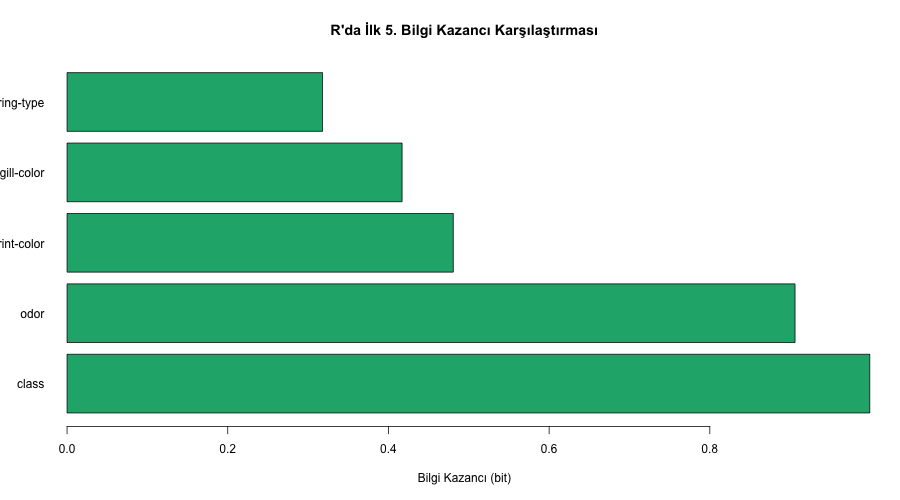

In [49]:
%%R -i mushrooms -w 900 -h 500

conditional_entropy_r <- function(df, feature, target = "class") {
  total <- nrow(df)
  groups <- split(df, df[[feature]])
  weighted_H <- 0
  for (g in groups) {
    p_val <- nrow(g) / total
    target_probs <- prop.table(table(g[[target]]))
    weighted_H <- weighted_H + p_val * entropy_r(as.numeric(target_probs))
  }
  weighted_H
}

H_before <- entropy_r(as.numeric(prop.table(table(mushrooms$class))))
cat("Bölmeden ÖNCE H(class) =", round(H_before, 4), "bit\n\n")

features <- c(colnames(mushrooms))
features <- features[features %in% colnames(mushrooms)]

kazanclar <- sapply(features, function(f) H_before - conditional_entropy_r(mushrooms, f))

kazanc_df <- data.frame(ozellik = names(kazanclar), bilgi_kazanci = as.numeric(kazanclar))
kazanc_df <- kazanc_df[order(-kazanc_df$bilgi_kazanci), ]
print(kazanc_df)

barplot(kazanc_df$bilgi_kazanci[1:5], names.arg = kazanc_df$ozellik[1:5], horiz = TRUE, las = 1,
        col = "#1baf7a", main = "R'da İlk 5. Bilgi Kazancı Karşılaştırması", xlab = "Bilgi Kazancı (bit)")


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Entropi, bilgi teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | — | Genel olasılık temelleri (entropi için önkoşul) |
| [Christopher Olah — Visual Information Theory](https://colah.github.io/posts/2015-09-Visual-Information/) | — | Entropi/KL'nin en iyi görsel anlatımlarından biri |
| [3Blue1Brown — Entropy (bağlamsal)](https://www.3blue1brown.com) | — | Matematiksel sezgi |
| [Kaggle — Mushroom Classification](https://www.kaggle.com/datasets/uciml/mushroom-classification) | Veri | mushrooms.csv kaynağı |
| [Kaggle — SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) | Veri | spam.csv kaynağı |
| [Kaggle — Digit Recognizer (MNIST)](https://www.kaggle.com/competitions/digit-recognizer/data) | Veri | train.csv kaynağı |